In [1]:
import os
import sys

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from src.model import RegularizedLogisticRegression
from src.optimizer import GradientDescentOptimizer

# **Decision Boundary Analysis**

This notebook visualizes how regularization affects decision boundaries.

We use a 2D dataset to make model behavior interpretable.

We compare:

- No regularization
- L2 regularization (smooth shrinkage)
- L1 regularization (sparsity)

The goal is to understand how λ controls model complexity.

In [2]:
from sklearn.datasets import make_classification

# 2D dataset for visualization
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

In [3]:
# Standardization (CRITICAL for GD)
X = (X - X.mean(axis=0)) / X.std(axis=0)

## **Model Comparison (No Reg vs L2 vs L1)**

All models use:
- Same initialization
- Same dataset
- Same hyperparameters

Only regularization changes.

In [4]:
# -----------------------------
# Decision Boundary Comparison
# -----------------------------

# No Regularization
np.random.seed(42)
model_none = RegularizedLogisticRegression(
    learning_rate=0.01,
    n_iterations=2000,
    lambda_=0.0,
    penalty=None
)
opt_none = GradientDescentOptimizer()
model_none = opt_none.train(model_none, X, y)


# L2 Regularization
np.random.seed(42)
model_l2 = RegularizedLogisticRegression(
    learning_rate=0.01,
    n_iterations=2000,
    lambda_=0.1,
    penalty="l2"
)
opt_l2 = GradientDescentOptimizer()
model_l2 = opt_l2.train(model_l2, X, y)


# L1 Regularization
np.random.seed(42)
model_l1 = RegularizedLogisticRegression(
    learning_rate=0.01,
    n_iterations=2000,
    lambda_=0.1,
    penalty="l1"
)
opt_l1 = GradientDescentOptimizer()
model_l1 = opt_l1.train(model_l1, X, y)

In [5]:
import os

def plot_decision_boundary(model, X, y, title, filename=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5)) 

    plt.contourf(xx, yy, probs, levels=50, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

    plt.title(title)

    if filename:
        os.makedirs("../experiments", exist_ok=True)
        plt.savefig(f"../experiments/{filename}", dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

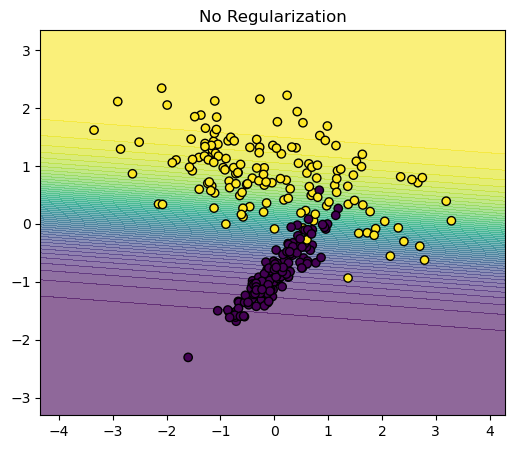

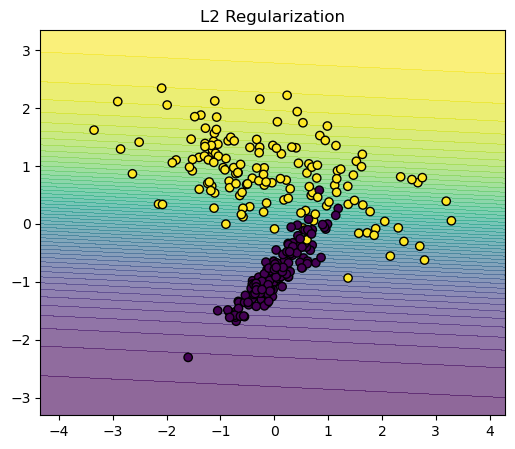

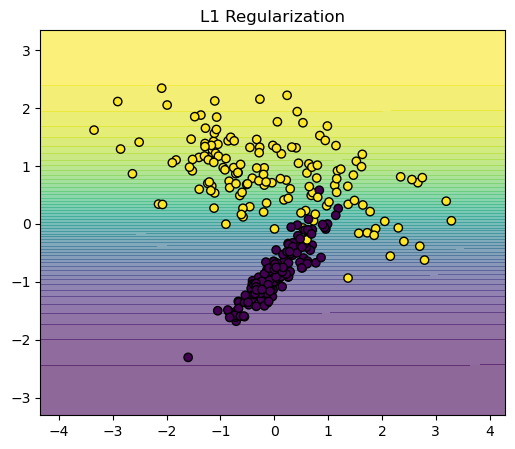

In [6]:
plot_decision_boundary(
    model_none, X, y,
    "No Regularization",
    filename="decision_boundary_no_reg.png"
)

plot_decision_boundary(
    model_l2, X, y,
    "L2 Regularization",
    filename="decision_boundary_l2.png"
)

plot_decision_boundary(
    model_l1, X, y,
    "L1 Regularization",
    filename="decision_boundary_l1.png"
)

## **Observations**

- Without regularization, the model fits the data more aggressively, resulting in a sharper decision boundary.

- L2 regularization produces a smoother boundary by shrinking weights uniformly. The transition between classes becomes less steep.

- L1 drove w[0] to near zero (~0), making the boundary almost perfectly axis-aligned. Even in 2D, the sparsity effect is visible.

- Increasing λ would further smooth the boundary (L2) or increase sparsity (L1), potentially leading to underfitting.

This demonstrates how regularization acts as a control mechanism for model complexity.